# Predictive Modeling Using Machine Learning
## Telco Customer Churn Prediction

**Internship Task:** Predictive Modeling Using Machine Learning  
**Objective:** Predict whether a telecom customer is likely to churn using supervised machine learning.

This project compares **Logistic Regression, Decision Tree, and Random Forest** models and evaluates them using Accuracy, Precision, Recall, F1-score, Confusion Matrix, ROC Curve, and ROC-AUC.

> **Tutorial reference:** The internship tutorial demonstrates binary classification, confusion matrices, ROC curves, thresholds, and AUC. This notebook applies those concepts to a structured customer-churn problem rather than copying the tutorial's image-classification implementation.


## 1. Problem Statement

Customer churn is a major business problem for subscription-based companies. The goal of this project is to build a binary classification model that predicts whether a customer will **leave (`Churn = 1`)** or **stay (`Churn = 0`)**.

### Business objective
A useful churn model can help a telecom company identify higher-risk customers and prioritize retention efforts.

### Modeling objective
We will:
- prepare the customer data,
- encode categorical variables,
- split data into training and testing sets,
- train three supervised learning models,
- compare their performance,
- analyze the confusion matrix and ROC-AUC,
- identify important predictive features.


## 2. Dataset

We use the **IBM Telco Customer Churn** dataset. Each row represents a customer and includes demographic information, subscribed services, contract/account information, and the `Churn` target.

Source: IBM sample dataset / IBM-managed GitHub repository.


In [1]:
# Import libraries

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve, roc_auc_score
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load dataset

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully.
Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Initial inspection

print("Columns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).head(10))

print("\nDuplicate rows:", df.duplicated().sum())

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:


,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object



Missing values:


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0



Duplicate rows: 0


## 3. Data Cleaning

The dataset contains `TotalCharges` as a text field in the raw file because some records contain blank values. We convert it to numeric and let the preprocessing pipeline handle missing values.

`customerID` is an identifier rather than a useful predictive feature, so it is removed.

We also remove the original text target after converting `Churn` into a binary numeric target.


In [4]:
# Clean and prepare the target

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

# Remove identifier
df = df.drop(columns=["customerID"])

print("Cleaned shape:", df.shape)
print("\nChurn distribution:")
display(df["Churn"].value_counts())
print("\nChurn rate: {:.2f}%".format(df["Churn"].mean() * 100))

Cleaned shape: (7043, 20)

Churn distribution:


,count
Churn,
0,5174
1,1869



Churn rate: 26.54%


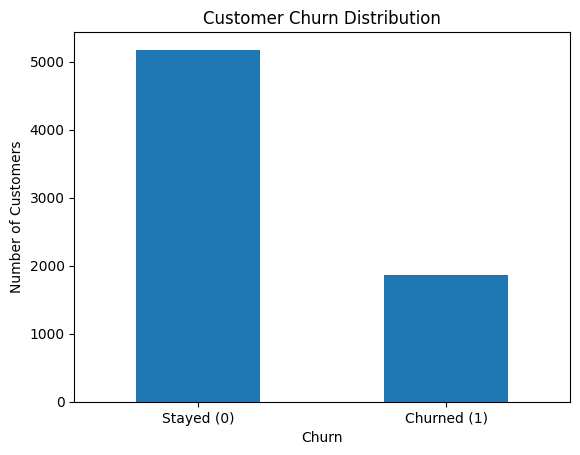

Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.00,0.000,0.0000,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.000,55.0000,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.350,89.8500,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.45,1397.475,3794.7375,8684.80
Churn,7043.0,0.265370,0.441561,0.00,0.00,0.000,1.0000,1.00


In [5]:
# Basic exploratory analysis

fig, ax = plt.subplots()
df["Churn"].value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_xticklabels(["Stayed (0)", "Churned (1)"], rotation=0)
ax.set_ylabel("Number of Customers")
ax.set_title("Customer Churn Distribution")
plt.show()

print("Descriptive statistics:")
display(df.describe().T)

## 4. Train-Test Split

The target is `Churn`.

We use an **80/20 split** and `stratify=y` so that the churn proportion remains approximately consistent in both training and testing data.


In [6]:
# Separate features and target

X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 5634
Testing samples: 1409


In [7]:
# Identify numeric and categorical features

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:", numeric_features)
print("\nCategorical features:", categorical_features)

Numeric features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## 5. Preprocessing

Machine-learning algorithms cannot directly use text categories such as `Contract` or `InternetService`.

We therefore:
- impute missing numeric values with the median,
- standardize numeric variables for Logistic Regression,
- impute missing categorical values with the most frequent category,
- one-hot encode categorical variables.

The preprocessing is placed inside a `Pipeline` so that transformations are learned from the training data only.


In [8]:
# Build preprocessing pipelines

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


## 6. Train Multiple Classification Models

We compare three models:

1. **Logistic Regression** — a strong and interpretable baseline for binary classification.
2. **Decision Tree** — captures non-linear decision rules.
3. **Random Forest** — combines multiple decision trees and can capture more complex patterns.


In [9]:
# Define models

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,
        min_samples_split=10,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1
    )
}

trained_models = {}
results = []

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

    trained_models[name] = pipe

results_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False)
display(results_df.round(4))

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8055,0.6572,0.5588,0.6040,0.8419
2,Random Forest,0.8013,0.6610,0.5160,0.5796,0.8387
1,Decision Tree,0.7913,0.6342,0.5053,0.5625,0.8351


## 7. Detailed Model Evaluation

Accuracy alone can be misleading when the target classes are not perfectly balanced. We therefore examine precision, recall, F1-score, and ROC-AUC.

For churn prediction, **recall is especially important** because missing a customer who is actually going to churn can mean losing an opportunity for retention.


In [10]:
# Classification reports

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    print("=" * 70)
    print(name)
    print("=" * 70)
    print(classification_report(
        y_test, y_pred,
        target_names=["Stayed", "Churned"]
    ))

Logistic Regression
              precision    recall  f1-score   support

      Stayed       0.85      0.89      0.87      1035
     Churned       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

Decision Tree
              precision    recall  f1-score   support

      Stayed       0.83      0.89      0.86      1035
     Churned       0.63      0.51      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409

Random Forest
              precision    recall  f1-score   support

      Stayed       0.84      0.90      0.87      1035
     Churned       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79   

Best model by ROC-AUC: Logistic Regression


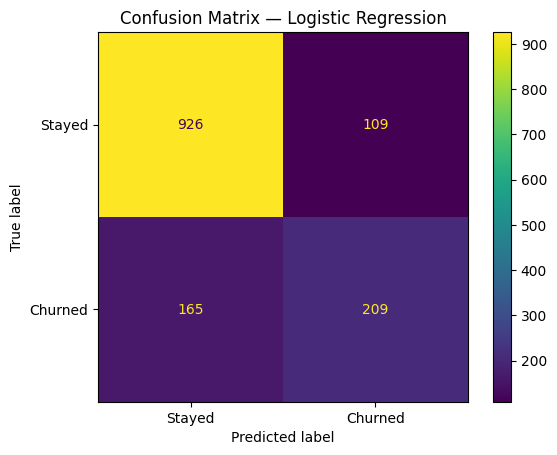

In [11]:
# Confusion matrix for the best ROC-AUC model

best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

best_pred = best_model.predict(X_test)

print("Best model by ROC-AUC:", best_model_name)

cm = confusion_matrix(y_test, best_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Stayed", "Churned"]
)
disp.plot()
plt.title(f"Confusion Matrix — {best_model_name}")
plt.show()

## 8. ROC Curve and AUC

The ROC curve evaluates the classifier across different probability thresholds by comparing the **True Positive Rate** with the **False Positive Rate**.

The **ROC-AUC** summarizes the model's ability to distinguish between the two classes across thresholds. A higher AUC indicates better ranking/separation performance.


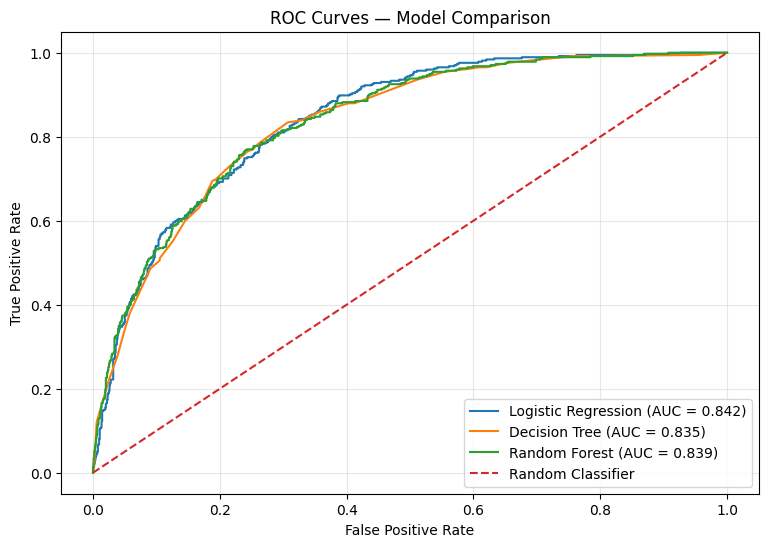

In [12]:
# ROC curves for all models

plt.figure(figsize=(9, 6))

for name, model in trained_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], "--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Model Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 9. Feature Importance

For the Random Forest model, feature importance can help identify which processed features contribute most to the model's decisions.

Because categorical variables were one-hot encoded, the feature names are extracted from the preprocessing pipeline.


,Importance
num__tenure,0.142300
num__TotalCharges,0.125736
cat__Contract_Month-to-month,0.098675
num__MonthlyCharges,0.084091
cat__OnlineSecurity_No,0.053988
cat__InternetService_Fiber optic,0.048479
cat__TechSupport_No,0.043142
cat__PaymentMethod_Electronic check,0.041733
cat__Contract_Two year,0.031065
cat__InternetService_DSL,0.020823


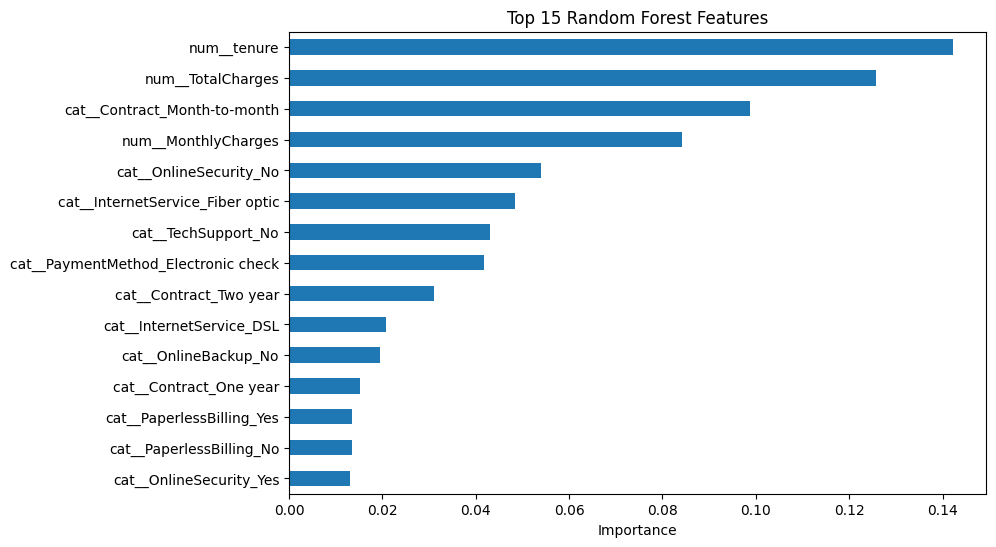

In [13]:
# Feature importance from Random Forest

rf_pipeline = trained_models["Random Forest"]

feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()
rf_model = rf_pipeline.named_steps["model"]

importance = pd.Series(
    rf_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

display(importance.head(15).to_frame("Importance"))

plt.figure(figsize=(9, 6))
importance.head(15).sort_values().plot(kind="barh")
plt.xlabel("Importance")
plt.title("Top 15 Random Forest Features")
plt.show()

In [14]:
# Final model comparison

final_results = results_df.copy()
display(final_results.round(4))

best_by_auc = final_results.iloc[0]
print(
    f"Best model by ROC-AUC: {best_by_auc['Model']} "
    f"with ROC-AUC = {best_by_auc['ROC-AUC']:.4f}"
)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8055,0.6572,0.5588,0.6040,0.8419
2,Random Forest,0.8013,0.6610,0.5160,0.5796,0.8387
1,Decision Tree,0.7913,0.6342,0.5053,0.5625,0.8351


Best model by ROC-AUC: Logistic Regression with ROC-AUC = 0.8419


## 10. Key Findings

After running the notebook, use the generated metrics to summarize:

- Which model achieved the strongest ROC-AUC?
- Which model achieved the strongest recall for churn?
- How many true positives, true negatives, false positives, and false negatives appear in the best model's confusion matrix?
- Which customer/service features were most important in the Random Forest?
- Why might recall matter to a retention team?

### Business interpretation

The model should be treated as a **decision-support tool**, not as an automatic decision maker. A telecom company could use high-risk predictions to prioritize customers for retention offers, service reviews, or proactive support.


## 11. Conclusion

This project demonstrates an end-to-end supervised machine-learning workflow for binary classification:

**Data → Cleaning → Preprocessing → Train/Test Split → Model Training → Prediction → Evaluation → Business Interpretation**

The project also applies the concepts highlighted in the internship tutorial — **confusion matrices, ROC curves, classification thresholds, and AUC** — to a practical customer-churn prediction problem.

### Skills demonstrated
- Python and Pandas
- Data preprocessing
- Categorical encoding
- Logistic Regression
- Decision Trees
- Random Forest
- Model evaluation
- Confusion Matrix
- ROC Curve
- ROC-AUC
- Feature importance
- Business interpretation


## References

1. IBM Telco Customer Churn dataset:  
   https://github.com/IBM/telco-customer-churn-on-icp4d/blob/master/data/Telco-Customer-Churn.csv

2. Internship tutorial reference: DigitalSreeni / Python for Microscopists — binary classification, confusion matrix, ROC and AUC.

3. scikit-learn documentation for ROC-AUC:  
   https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html
